# Exercise 01: Line chart with styles

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../data/checking-logs.sqlite')


## Getting commits by users

In [2]:
commits = pd.read_sql("""
SELECT DATE(timestamp) as date, COUNT(*) as commits
FROM checker
WHERE uid LIKE 'user_%'
GROUP BY date
""", conn)

In [3]:
views = pd.read_sql("""
SELECT DATE(datetime) as date, COUNT(*) as views
FROM pageviews
WHERE uid LIKE 'user_%'
GROUP BY date
""", conn)

## Corrections as needed

In [4]:
df = views.merge(commits, on='date', how='inner') # keeping only common dates
df.set_index('date', inplace=True) # setting date as index

## Plotting the figure

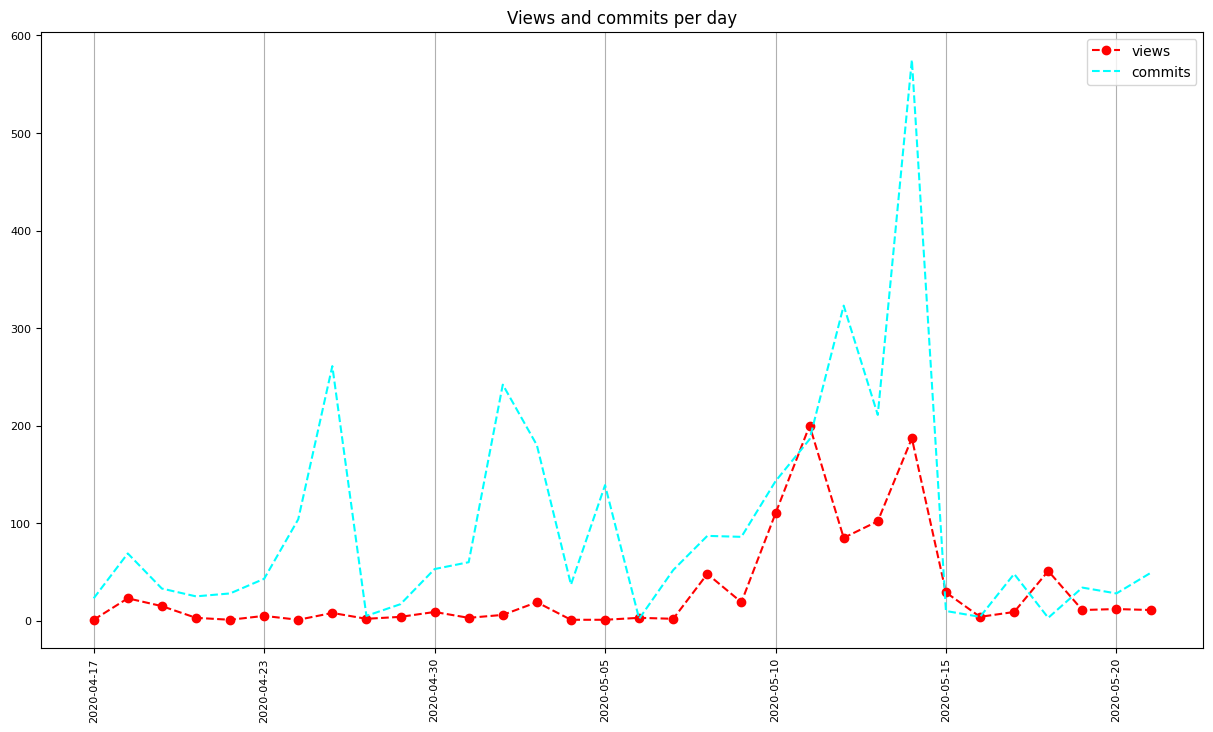

In [5]:
figure = df.plot(
    figsize=(15,8),
    fontsize=8,
    style=['--o', '--'],
    color=['red', 'cyan'],
    title='Views and commits per day',
    rot=90
)

figure.set_xlabel('')
figure.xaxis.grid(True)  

## Last part

In [6]:
(df['views'] > 150).sum()

np.int64(2)

##### How many times was the number of views larger than 150? 

##### The answer is 2

## Closing the connection

In [7]:
conn.close()